# Metropolis-Hastings Algorithm Tutorial

This notebook provides a comprehensive introduction to the Metropolis-Hastings algorithm, a fundamental Markov Chain Monte Carlo (MCMC) method used for sampling from probability distributions.

## 1. Introduction to Metropolis-Hastings Algorithm

The Metropolis-Hastings algorithm is a Markov Chain Monte Carlo (MCMC) method for obtaining a sequence of random samples from a probability distribution from which direct sampling is difficult. The algorithm is particularly useful in Bayesian statistics and computational physics.

### Key Concepts:
- **Markov Chain**: A sequence of random variables where the future state depends only on the current state
- **Proposal Distribution**: A distribution used to suggest new states
- **Acceptance Probability**: The probability of accepting a proposed state
- **Stationary Distribution**: The target distribution we want to sample from

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, multivariate_normal
import time

# Set up plotting parameters
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 14

## 2. Basic Metropolis-Hastings Algorithm

The basic Metropolis-Hastings algorithm works as follows:

1. Initialize the chain with a starting point x₀
2. For each iteration t:
   - Generate a candidate x* from a proposal distribution q(x*|xₜ₋₁)
   - Calculate the acceptance probability: α = min(1, [p(x*)q(xₜ₋₁|x*)] / [p(xₜ₋₁)q(x*|xₜ₋₁)])
   - Accept the candidate with probability α (set xₜ = x*)
   - Otherwise reject (set xₜ = xₜ₋₁)
3. Repeat for desired number of iterations

Where p(x) is the target distribution (up to a normalizing constant).

## 3. Implementation: Sampling from a 1D Distribution

Let's implement the Metropolis-Hastings algorithm to sample from a 1D distribution. We'll use a normal distribution as our target and a normal distribution as our proposal.

In [2]:
def target_distribution_1d(x):
    """Target distribution: mixture of two normal distributions"""
    return 0.3 * norm.pdf(x, loc=-2, scale=1) + 0.7 * norm.pdf(x, loc=3, scale=1.5)

def proposal_distribution(x, step_size=1.0):
    """Proposal distribution: normal distribution centered at current x"""
    return np.random.normal(x, step_size)

def metropolis_hastings_1d(target_func, proposal_func, initial_x, num_samples, step_size=1.0):
    """Metropolis-Hastings algorithm for 1D distributions"""
    samples = np.zeros(num_samples)
    current_x = initial_x
    accepted = 0
    
    for i in range(num_samples):
        # Propose new state
        proposed_x = proposal_func(current_x, step_size)
        
        # Calculate acceptance probability
        # Since proposal is symmetric (normal), q(x*|x) = q(x|x*)
        # So acceptance probability simplifies to min(1, p(x*)/p(x))
        acceptance_prob = min(1, target_func(proposed_x) / target_func(current_x))
        
        # Accept or reject
        if np.random.random() < acceptance_prob:
            current_x = proposed_x
            accepted += 1
        
        samples[i] = current_x
    
    acceptance_rate = accepted / num_samples
    return samples, acceptance_rate

# Run the algorithm
np.random.seed(42)
num_samples = 10000
initial_x = 0
step_size = 2.0

samples, acceptance_rate = metropolis_hastings_1d(
    target_distribution_1d, proposal_distribution, initial_x, num_samples, step_size
)

print(f"Acceptance rate: {acceptance_rate:.2%}")
print(f"Sample mean: {np.mean(samples):.4f}")
print(f"Sample std: {np.std(samples):.4f}")

Acceptance rate: 68.90%
Sample mean: 1.7081
Sample std: 2.5431


## 4. Visualizing the Results

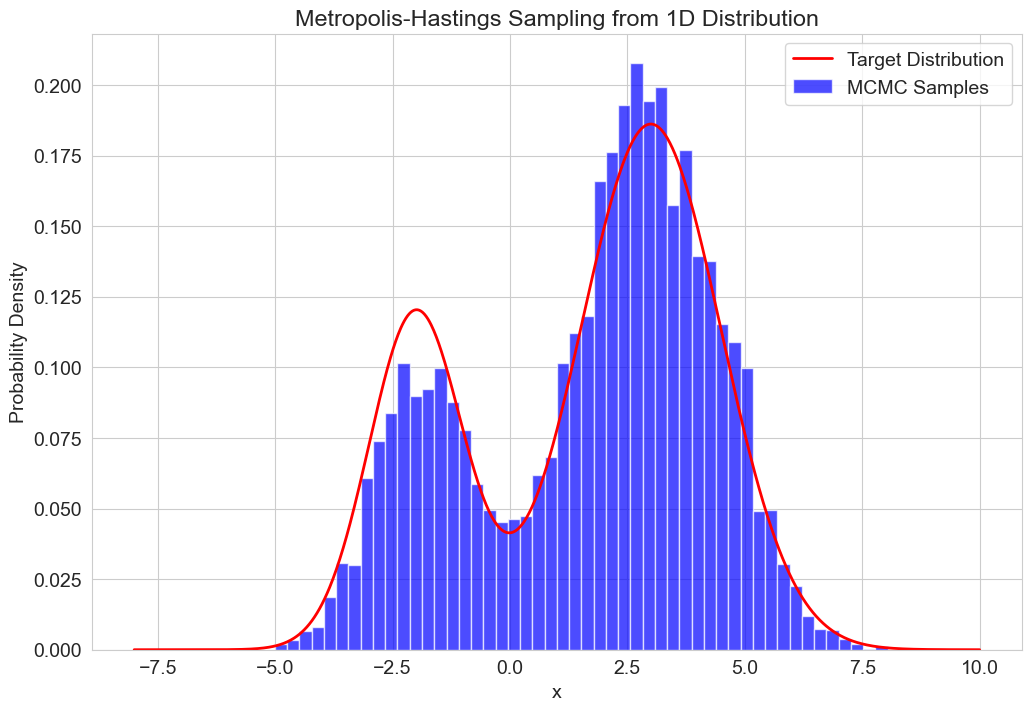

In [3]:
# Plot the results
x_values = np.linspace(-8, 10, 1000)
y_values = target_distribution_1d(x_values)

plt.figure(figsize=(12, 8))

# Plot target distribution
plt.plot(x_values, y_values, 'r-', linewidth=2, label='Target Distribution')

# Plot histogram of samples
plt.hist(samples, bins=50, density=True, alpha=0.7, color='blue', label='MCMC Samples')

plt.title('Metropolis-Hastings Sampling from 1D Distribution')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

## 5. Analyzing Convergence and Mixing

Let's analyze the convergence of the Markov chain by looking at the trace plot and autocorrelation.

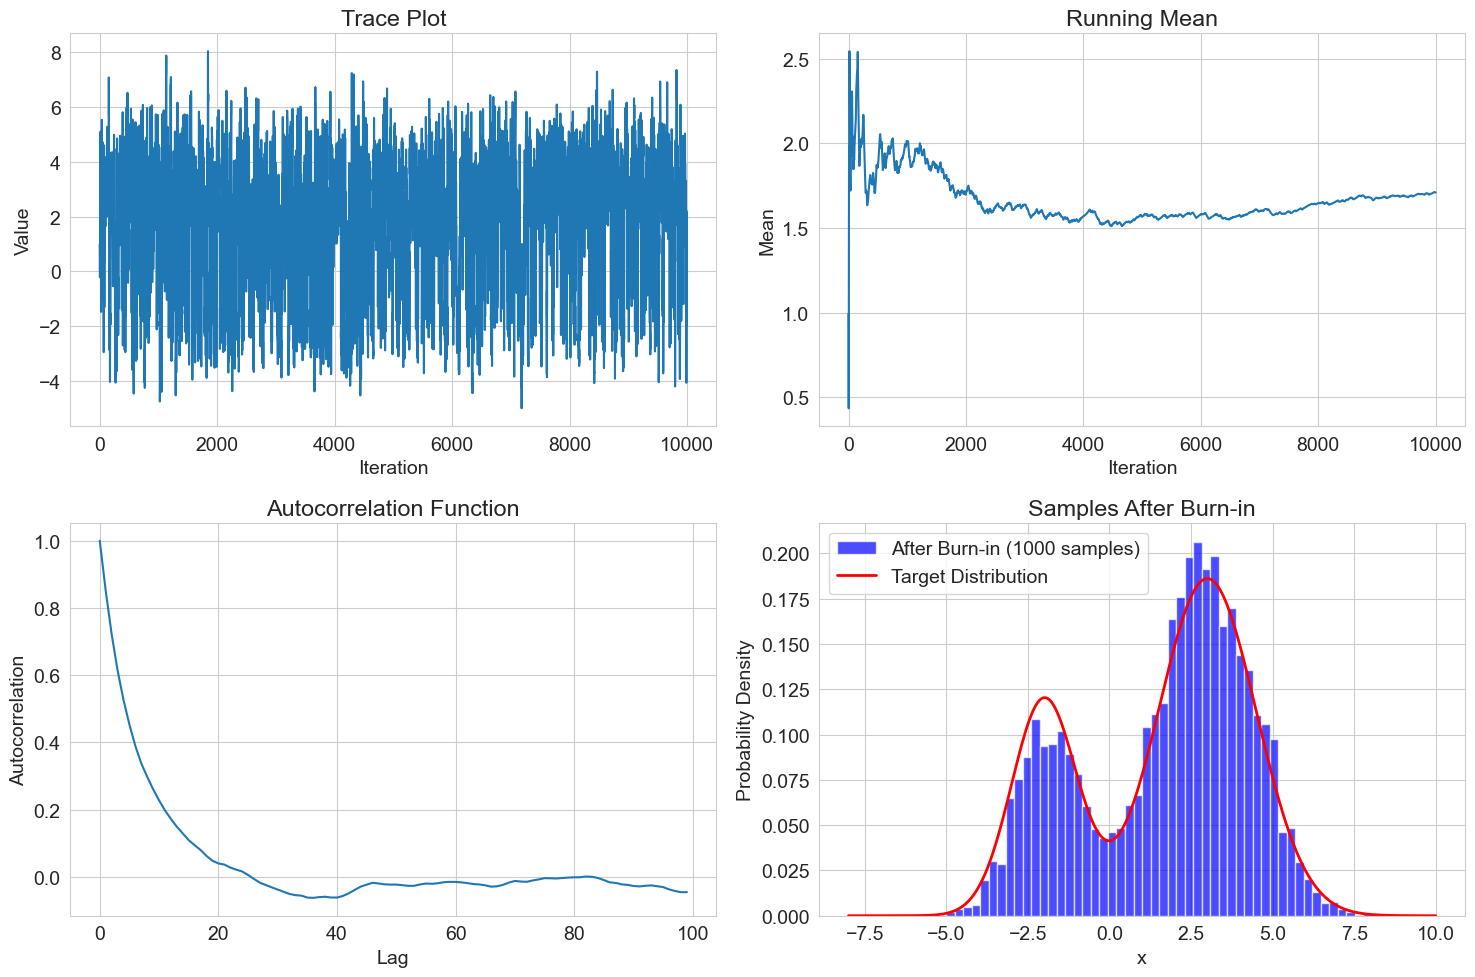

In [4]:
# Create trace plot
plt.figure(figsize=(15, 10))

# Trace plot
plt.subplot(2, 2, 1)
plt.plot(samples)
plt.title('Trace Plot')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.grid(True)

# Running mean
plt.subplot(2, 2, 2)
running_mean = np.cumsum(samples) / np.arange(1, len(samples) + 1)
plt.plot(running_mean)
plt.title('Running Mean')
plt.xlabel('Iteration')
plt.ylabel('Mean')
plt.grid(True)

# Autocorrelation plot
plt.subplot(2, 2, 3)
def autocorrelation(x, max_lag=100):
    n = len(x)
    autocorr = np.zeros(max_lag)
    x_centered = x - np.mean(x)
    
    for lag in range(max_lag):
        if lag == 0:
            autocorr[lag] = 1
        else:
            autocorr[lag] = np.sum(x_centered[:n-lag] * x_centered[lag:]) / np.sum(x_centered**2)
    
    return autocorr

autocorr = autocorrelation(samples)
plt.plot(autocorr)
plt.title('Autocorrelation Function')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)

# Histogram with different burn-in periods
plt.subplot(2, 2, 4)
burn_in = 1000
plt.hist(samples[burn_in:], bins=50, density=True, alpha=0.7, color='blue', label=f'After Burn-in ({burn_in} samples)')
plt.plot(x_values, y_values, 'r-', linewidth=2, label='Target Distribution')
plt.title('Samples After Burn-in')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 6. Effect of Step Size on Performance

The step size in the proposal distribution significantly affects the algorithm's performance. Let's compare different step sizes.

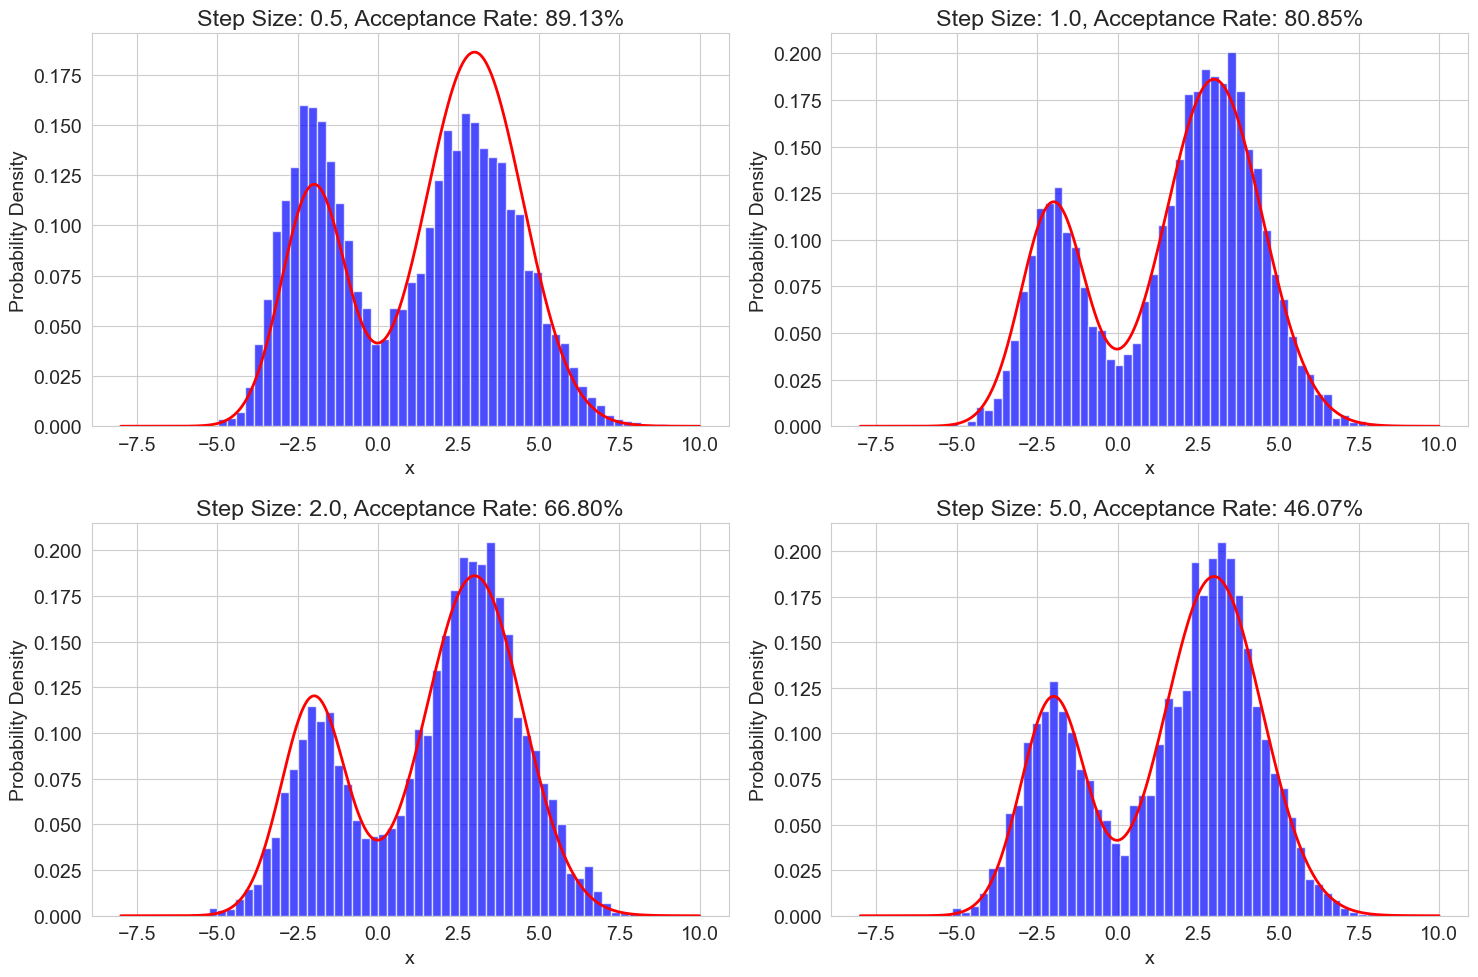

Performance Metrics for Different Step Sizes:
------------------------------------------------------------
Step Size: 0.5
  Acceptance Rate: 89.13%
  Effective Sample Size: 76

Step Size: 1.0
  Acceptance Rate: 80.85%
  Effective Sample Size: 200

Step Size: 2.0
  Acceptance Rate: 66.80%
  Effective Sample Size: 817

Step Size: 5.0
  Acceptance Rate: 46.07%
  Effective Sample Size: 1928



In [5]:
# Compare different step sizes
step_sizes = [0.5, 1.0, 2.0, 5.0]
results = {}

for step_size in step_sizes:
    samples, acceptance_rate = metropolis_hastings_1d(
        target_distribution_1d, proposal_distribution, initial_x, num_samples, step_size
    )
    results[step_size] = {
        'samples': samples,
        'acceptance_rate': acceptance_rate,
        'effective_sample_size': num_samples / (1 + 2 * np.sum(autocorrelation(samples)[1:100]))
    }

# Plot results
plt.figure(figsize=(15, 10))

for i, step_size in enumerate(step_sizes):
    plt.subplot(2, 2, i+1)
    plt.hist(results[step_size]['samples'], bins=50, density=True, alpha=0.7, color='blue')
    plt.plot(x_values, y_values, 'r-', linewidth=2)
    plt.title(f'Step Size: {step_size}, Acceptance Rate: {results[step_size]["acceptance_rate"]:.2%}')
    plt.xlabel('x')
    plt.ylabel('Probability Density')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Print performance metrics
print("Performance Metrics for Different Step Sizes:")
print("-" * 60)
for step_size in step_sizes:
    print(f"Step Size: {step_size}")
    print(f"  Acceptance Rate: {results[step_size]['acceptance_rate']:.2%}")
    print(f"  Effective Sample Size: {results[step_size]['effective_sample_size']:.0f}")
    print()

## 7. 2D Example: Sampling from a Bivariate Distribution

Now let's extend the algorithm to a 2D case, sampling from a bivariate normal distribution.

In [6]:
def target_distribution_2d(x):
    """Target distribution: 2D normal distribution"""
    mean = np.array([1, 2])
    cov = np.array([[1, 0.8], [0.8, 1]])
    return multivariate_normal.pdf(x, mean=mean, cov=cov)

def proposal_distribution_2d(x, step_size=1.0):
    """Proposal distribution: 2D normal distribution centered at current x"""
    return np.random.multivariate_normal(x, np.eye(2) * step_size**2)

def metropolis_hastings_2d(target_func, proposal_func, initial_x, num_samples, step_size=1.0):
    """Metropolis-Hastings algorithm for 2D distributions"""
    samples = np.zeros((num_samples, 2))
    current_x = initial_x
    accepted = 0
    
    for i in range(num_samples):
        # Propose new state
        proposed_x = proposal_func(current_x, step_size)
        
        # Calculate acceptance probability
        acceptance_prob = min(1, target_func(proposed_x) / target_func(current_x))
        
        # Accept or reject
        if np.random.random() < acceptance_prob:
            current_x = proposed_x
            accepted += 1
        
        samples[i] = current_x
    
    acceptance_rate = accepted / num_samples
    return samples, acceptance_rate

# Run the 2D algorithm
np.random.seed(42)
num_samples_2d = 5000
initial_x_2d = np.array([0, 0])
step_size_2d = 1.0

samples_2d, acceptance_rate_2d = metropolis_hastings_2d(
    target_distribution_2d, proposal_distribution_2d, initial_x_2d, num_samples_2d, step_size_2d
)

print(f"Acceptance rate: {acceptance_rate_2d:.2%}")
print(f"Sample mean: {np.mean(samples_2d, axis=0)}")
print(f"Sample covariance matrix:\n{np.cov(samples_2d.T)}")

Acceptance rate: 39.56%
Sample mean: [0.98752191 2.00096823]
Sample covariance matrix:
[[0.93973118 0.74928676]
 [0.74928676 0.90817681]]


## 8. Visualizing the 2D Results

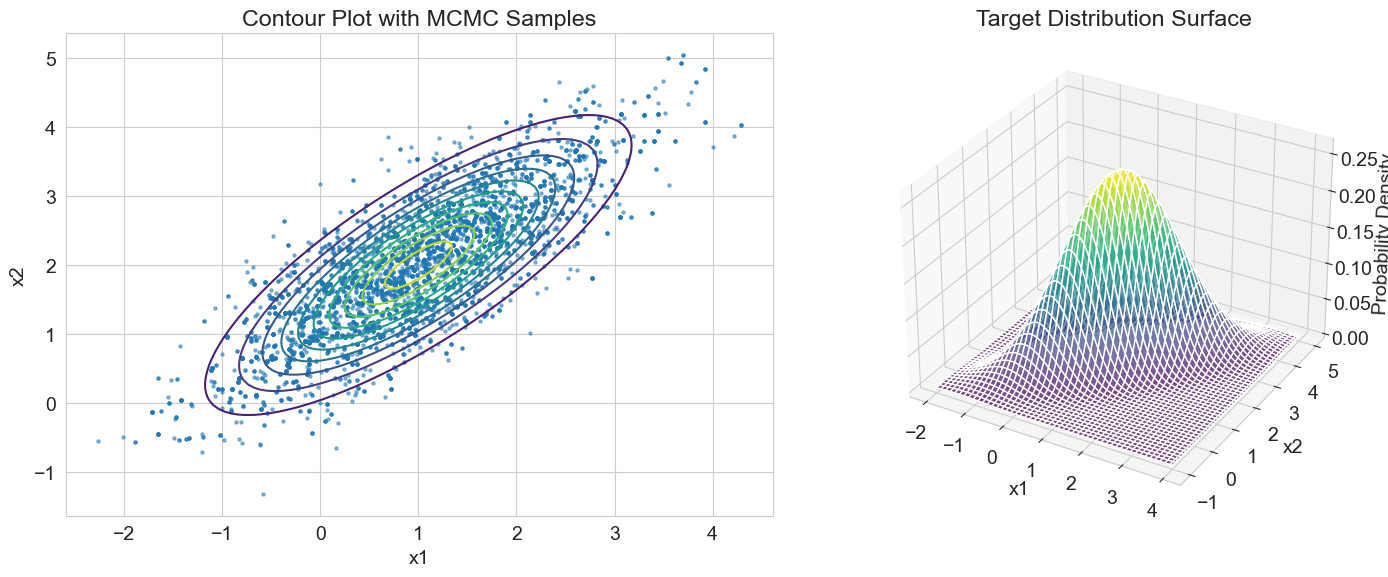

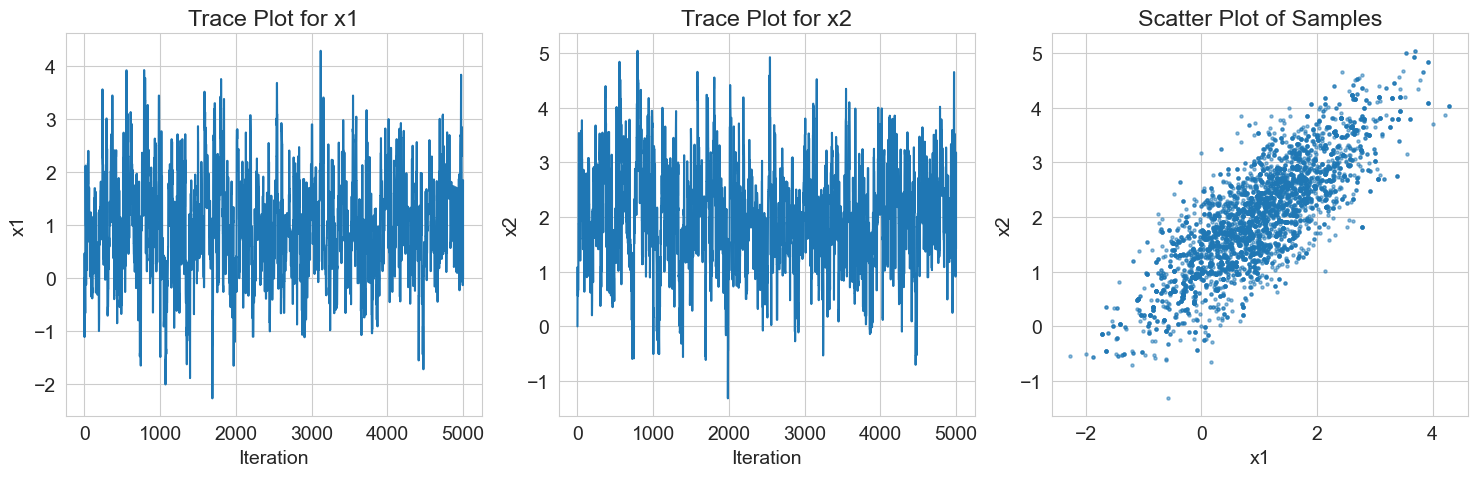

In [7]:
# Create a grid for the target distribution
x = np.linspace(-2, 4, 100)
y = np.linspace(-1, 5, 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = target_distribution_2d(np.array([X[i, j], Y[i, j]]))

# Plot the results
plt.figure(figsize=(15, 6))

# Contour plot with samples
plt.subplot(1, 2, 1)
plt.contour(X, Y, Z, levels=10, cmap='viridis')
plt.scatter(samples_2d[:, 0], samples_2d[:, 1], alpha=0.5, s=5)
plt.title('Contour Plot with MCMC Samples')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)

# 3D surface plot
ax = plt.subplot(1, 2, 2, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)
ax.set_title('Target Distribution Surface')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('Probability Density')

plt.tight_layout()
plt.show()

# Trace plots for each dimension
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(samples_2d[:, 0])
plt.title('Trace Plot for x1')
plt.xlabel('Iteration')
plt.ylabel('x1')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(samples_2d[:, 1])
plt.title('Trace Plot for x2')
plt.xlabel('Iteration')
plt.ylabel('x2')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.scatter(samples_2d[:, 0], samples_2d[:, 1], alpha=0.5, s=5)
plt.title('Scatter Plot of Samples')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)

plt.tight_layout()
plt.show()

## 9. Advanced Example: Bayesian Linear Regression

Let's apply the Metropolis-Hastings algorithm to a Bayesian linear regression problem.

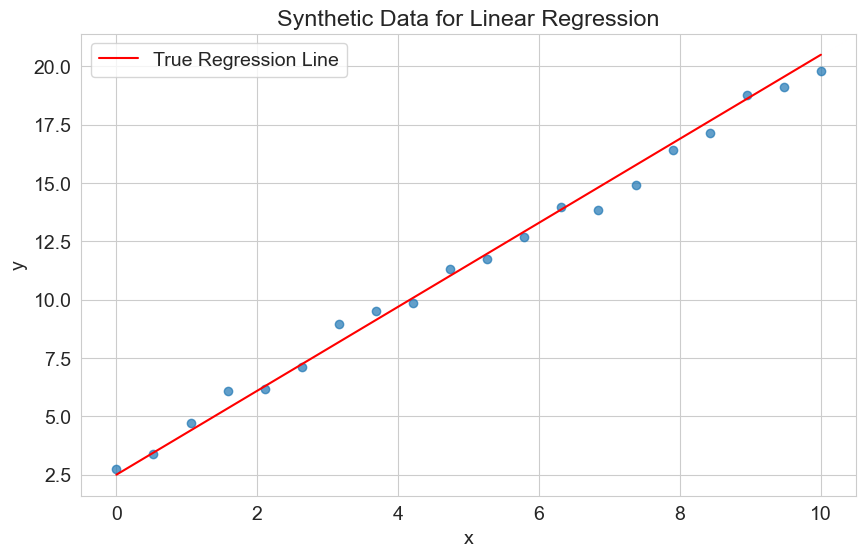

/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_84938/2620276245.py:69: RuntimeWarning: invalid value encountered in scalar divide
  acceptance_prob = min(1, posterior(proposed_params) / posterior(current_params))
/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_84938/2620276245.py:69: RuntimeWarning: divide by zero encountered in scalar divide
  acceptance_prob = min(1, posterior(proposed_params) / posterior(current_params))


Acceptance rate: 2.15%
True parameters: intercept=2.5, slope=1.8, sigma=0.5
Posterior means: intercept=2.86, slope=1.70, sigma=0.46


In [8]:
# Generate synthetic data
np.random.seed(42)
true_intercept = 2.5
true_slope = 1.8
true_sigma = 0.5

x_data = np.linspace(0, 10, 20)
y_data = true_intercept + true_slope * x_data + np.random.normal(0, true_sigma, size=len(x_data))

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, alpha=0.7)
plt.plot(x_data, true_intercept + true_slope * x_data, 'r-', label='True Regression Line')
plt.title('Synthetic Data for Linear Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# Define the likelihood function
def likelihood(params):
    intercept, slope, sigma = params
    if sigma <= 0:
        return 0
    
    y_pred = intercept + slope * x_data
    residuals = y_data - y_pred
    
    # Normal likelihood
    log_likelihood = -0.5 * np.sum((residuals / sigma)**2) - len(x_data) * np.log(sigma)
    return np.exp(log_likelihood)

# Define the prior distributions
def prior(params):
    intercept, slope, sigma = params
    
    # Normal priors for intercept and slope
    prior_intercept = norm.pdf(intercept, loc=0, scale=10)
    prior_slope = norm.pdf(slope, loc=0, scale=10)
    
    # Half-normal prior for sigma (positive only)
    if sigma > 0:
        prior_sigma = 2 * norm.pdf(sigma, loc=0, scale=1)
    else:
        prior_sigma = 0
    
    return prior_intercept * prior_slope * prior_sigma

# Define the posterior (up to normalizing constant)
def posterior(params):
    return likelihood(params) * prior(params)

# Metropolis-Hastings for Bayesian regression
def metropolis_hastings_regression(num_samples, initial_params, step_sizes):
    samples = np.zeros((num_samples, 3))
    current_params = initial_params
    accepted = 0
    
    for i in range(num_samples):
        # Propose new parameters
        proposed_params = np.array([
            np.random.normal(current_params[0], step_sizes[0]),  # intercept
            np.random.normal(current_params[1], step_sizes[1]),  # slope
            np.abs(np.random.normal(current_params[2], step_sizes[2]))  # sigma (positive)
        ])
        
        # Calculate acceptance probability
        acceptance_prob = min(1, posterior(proposed_params) / posterior(current_params))
        
        # Accept or reject
        if np.random.random() < acceptance_prob:
            current_params = proposed_params
            accepted += 1
        
        samples[i] = current_params
    
    acceptance_rate = accepted / num_samples
    return samples, acceptance_rate

# Run the MCMC
num_samples_reg = 10000
initial_params = [0, 0, 1]  # intercept, slope, sigma
step_sizes = [0.5, 0.5, 0.1]  # step sizes for each parameter

samples_reg, acceptance_rate_reg = metropolis_hastings_regression(
    num_samples_reg, initial_params, step_sizes
)

print(f"Acceptance rate: {acceptance_rate_reg:.2%}")
print(f"True parameters: intercept={true_intercept}, slope={true_slope}, sigma={true_sigma}")
print(f"Posterior means: intercept={np.mean(samples_reg[:, 0]):.2f}, slope={np.mean(samples_reg[:, 1]):.2f}, sigma={np.mean(samples_reg[:, 2]):.2f}")

## 10. Visualizing the Bayesian Regression Results

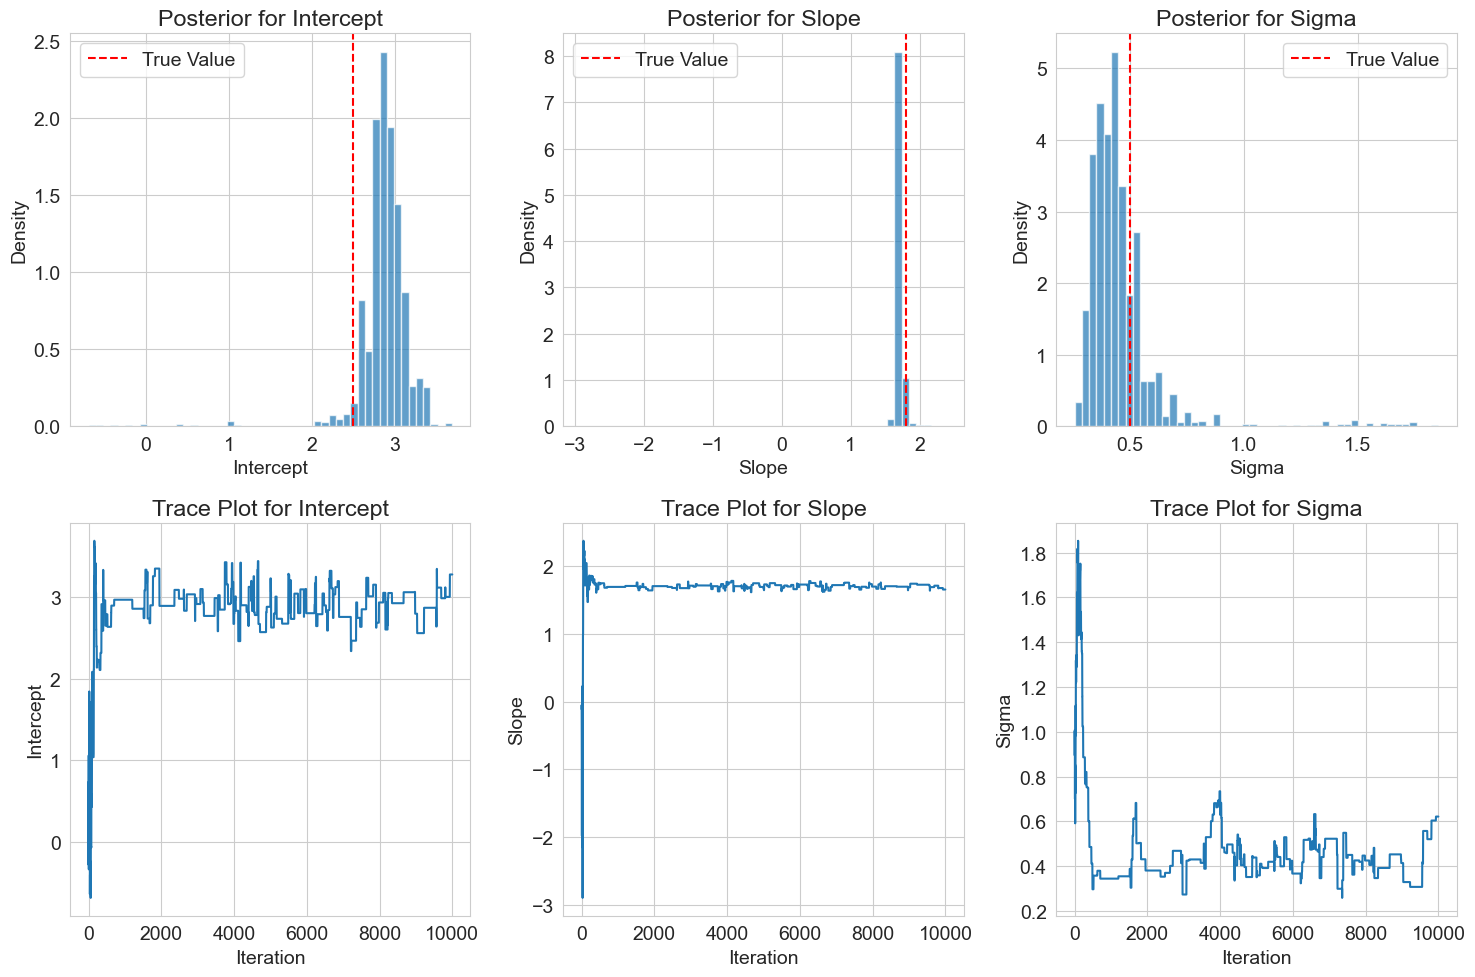

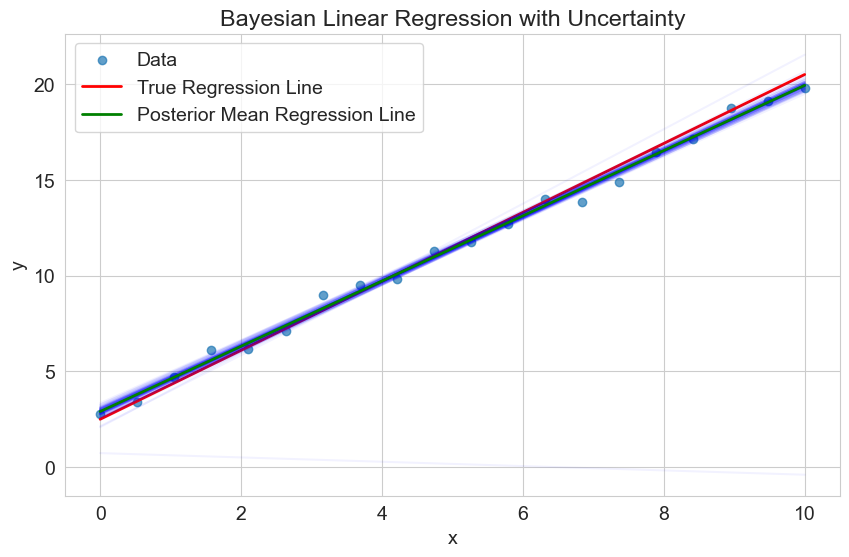

In [9]:
# Plot the posterior distributions
plt.figure(figsize=(15, 10))

# Posterior for intercept
plt.subplot(2, 3, 1)
plt.hist(samples_reg[:, 0], bins=50, density=True, alpha=0.7)
plt.axvline(true_intercept, color='r', linestyle='--', label='True Value')
plt.title('Posterior for Intercept')
plt.xlabel('Intercept')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Posterior for slope
plt.subplot(2, 3, 2)
plt.hist(samples_reg[:, 1], bins=50, density=True, alpha=0.7)
plt.axvline(true_slope, color='r', linestyle='--', label='True Value')
plt.title('Posterior for Slope')
plt.xlabel('Slope')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Posterior for sigma
plt.subplot(2, 3, 3)
plt.hist(samples_reg[:, 2], bins=50, density=True, alpha=0.7)
plt.axvline(true_sigma, color='r', linestyle='--', label='True Value')
plt.title('Posterior for Sigma')
plt.xlabel('Sigma')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Trace plots
burn_in = 1000
plt.subplot(2, 3, 4)
plt.plot(samples_reg[:, 0])
plt.title('Trace Plot for Intercept')
plt.xlabel('Iteration')
plt.ylabel('Intercept')
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(samples_reg[:, 1])
plt.title('Trace Plot for Slope')
plt.xlabel('Iteration')
plt.ylabel('Slope')
plt.grid(True)

plt.subplot(2, 3, 6)
plt.plot(samples_reg[:, 2])
plt.title('Trace Plot for Sigma')
plt.xlabel('Iteration')
plt.ylabel('Sigma')
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot regression lines with uncertainty
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, alpha=0.7, label='Data')

# Plot true regression line
plt.plot(x_data, true_intercept + true_slope * x_data, 'r-', linewidth=2, label='True Regression Line')

# Plot posterior regression lines
for i in range(0, num_samples_reg, 100):  # Sample every 100th iteration
    intercept = samples_reg[i, 0]
    slope = samples_reg[i, 1]
    plt.plot(x_data, intercept + slope * x_data, 'b-', alpha=0.05)

# Plot posterior mean regression line
mean_intercept = np.mean(samples_reg[burn_in:, 0])
mean_slope = np.mean(samples_reg[burn_in:, 1])
plt.plot(x_data, mean_intercept + mean_slope * x_data, 'g-', linewidth=2, label='Posterior Mean Regression Line')

plt.title('Bayesian Linear Regression with Uncertainty')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## 11. Conclusion

In this notebook, we've explored the Metropolis-Hastings algorithm through several examples:

1. **Basic Implementation**: We implemented the algorithm for sampling from a 1D mixture distribution
2. **Performance Analysis**: We examined how step size affects acceptance rate and mixing
3. **2D Extension**: We extended the algorithm to a 2D bivariate normal distribution
4. **Practical Application**: We applied the algorithm to Bayesian linear regression

### Key Takeaways:

- The Metropolis-Hastings algorithm allows sampling from complex distributions
- The choice of proposal distribution and step size significantly affects performance
- Convergence diagnostics like trace plots and autocorrelation are essential
- The algorithm is widely used in Bayesian statistics and computational physics

### Practical Tips:

- Aim for an acceptance rate between 20-50% for optimal performance
- Use multiple chains with different starting points to check convergence
- Consider thinning (keeping only every k-th sample) to reduce autocorrelation
- Always perform convergence diagnostics before using the samples

The Metropolis-Hastings algorithm is a powerful tool for Bayesian inference and has been widely used in various fields including physics, statistics, and machine learning.